In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from service import SeattleBuildingService
from BuildingInput import BuildingInput


In [2]:
service = SeattleBuildingService()


In [3]:
df_esti = pd.read_csv('./data/projet6_estimation.csv')

In [4]:
#row_dic = df_esti.loc[0].to_dict()
#input_obj = BuildingInput (**row.to_dict() )

#predictions = [service.predict ( BuildingInput (**row.to_dict() ) ) ["prediction_tCO2"] for _, row in df_esti.iterrows()]
#predictions = service.predict (row_dic )

predictions = [
    service.predict(BuildingInput(**row))["prediction_tCO2"]
    for row in df_esti.to_dict(orient="records")
]






In [5]:
# 2. Assignation des prédictions dans le DataFrame de test
data_test = df_esti.copy()
data_test["prediction"] = predictions


In [6]:
data_test["TotalGHGEmissions"].describe()

count     96.000000
mean      81.583750
std       81.843537
min        2.340000
25%       22.115000
50%       52.415000
75%       94.692500
max      359.090000
Name: TotalGHGEmissions, dtype: float64

In [7]:
data_test["prediction"].describe()

count     96.000000
mean      99.578854
std       55.649178
min       12.770000
25%       67.000000
50%       81.230000
75%      114.325000
max      251.150000
Name: prediction, dtype: float64

In [8]:
# Total cumulé réels vs prédits
total_reel = data_test["TotalGHGEmissions"].sum()
total_predit = data_test["prediction"].sum()
ratio_global_pct = (total_predit / total_reel) * 100
# Erreur Pourcentage Moyenne Absolue (MAPE)

mape = (
    np.abs(
        (data_test["TotalGHGEmissions"] - data_test["prediction"])
        / data_test["TotalGHGEmissions"]
    ).mean()
    * 100
)

# Erreur Médiane Pourcentage Absolue (MdAPE) - Résistante aux valeurs aberrantes
mdape = (
    np.abs(
        (data_test["TotalGHGEmissions"] - data_test["prediction"])
        / data_test["TotalGHGEmissions"]
    ).median()
    * 100
)

# 5. Affichage des résultats
print(f"--- RÉSULTATS GLOBAUX DU MODÈLE ---")
print(
    f"Volume réel total      : {total_reel:,.2f} tCO2e"
)
print(
    f"Volume prédit total     : {total_predit:,.2f} tCO2e"
)
print(
    f"Ratio global de volume  : {ratio_global_pct:.2f}% "
)
print(f"Erreur moyenne (MAPE)   : {mape:.2f}%")
print(f"Erreur médiane (MdAPE)  : {mdape:.2f}%")

--- RÉSULTATS GLOBAUX DU MODÈLE ---
Volume réel total      : 7,832.04 tCO2e
Volume prédit total     : 9,559.57 tCO2e
Ratio global de volume  : 122.06% 
Erreur moyenne (MAPE)   : 150.24%
Erreur médiane (MdAPE)  : 45.69%


In [9]:
data_test["ecart"] =data_test["TotalGHGEmissions"] - data_test["prediction"] 

data_test["ratio_pct"] = ( data_test["prediction"]/ data_test["TotalGHGEmissions"]) *100

data_test["ratio_erreur_pct"] = (
    (data_test["prediction"] - data_test["TotalGHGEmissions"])
    / data_test["TotalGHGEmissions"]
) * 100

In [12]:
display (data_test[["BuildingType", "TotalGHGEmissions" ,"prediction", "ecart", "ratio_pct" , "ratio_erreur_pct", "BuildingAge"] ].sort_values(by ="BuildingAge"))

,BuildingType,TotalGHGEmissions,prediction,ecart,ratio_pct,ratio_erreur_pct,BuildingAge
27,SPS-District K-12,80.08,128.85,-48.77,160.901598,60.901598,6
91,SPS-District K-12,124.77,150.55,-25.78,120.662018,20.662018,7
59,SPS-District K-12,24.42,81.97,-57.55,335.667486,235.667486,8
14,SPS-District K-12,359.09,229.01,130.08,63.775098,-36.224902,8
40,SPS-District K-12,226.06,156.65,69.41,69.295762,-30.704238,9
...,...,...,...,...,...,...,...
77,SPS-District K-12,94.85,110.79,-15.94,116.805482,16.805482,91
90,SPS-District K-12,46.70,67.12,-20.42,143.725910,43.725910,91
41,NonResidential,148.11,104.87,43.24,70.805482,-29.194518,95
42,NonResidential,22.39,41.17,-18.78,183.876731,83.876731,107


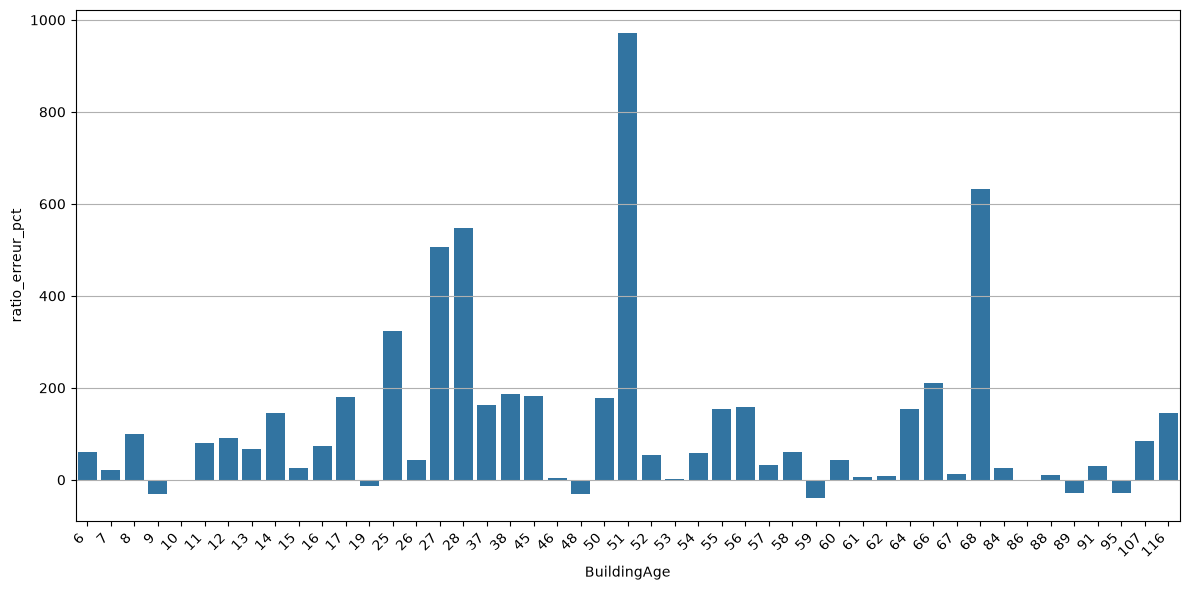

In [13]:
plt.figure(figsize=(12,6))
consommation_par_type = data_test.groupby('BuildingAge')['ratio_erreur_pct'].mean().sort_values(ascending=True).round(0)
sns.barplot(data=consommation_par_type)
plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y')
plt.tight_layout()